# Дипломная работа: Детекция переутомления спортсмена
## Гибридная модель CNN + LSTM на данных носимых датчиков

**Цель:** Разработка системы автоматического определения переутомления спортсмена

**Датасеты (3 источника):**
- **Zenodo Running IMU** (19 субъектов) — бег 400м до/после Beep Test, IMU 256 Hz
- **4TU Marotta** (19 субъектов) — бег 4км + протокол утомления до RPE>16, IMU 240 Hz
- **PhysioNet Wearable Device** (до 31 субъекта) — Empatica E4: ACC(32Hz), BVP(64Hz), EDA(4Hz), TEMP(4Hz), HR(1Hz). Протоколы AEROBIC (cycling) и ANAEROBIC (Wingate)

**Данные (dual-branch):**
- `X_imu`:   (N, 100, 6) — ax, ay, az, gx, gy, gz
- `X_physio`: (N, 100, 4) — bvp, eda, temp, hr
- `has_physio`: маска наличия физиологических каналов

**Модель:** CNN + LSTM (двухветочная, ~474K параметров)
- IMU-ветка: 3×Conv1D → 256-dim
- Physio-ветка: 3×Conv1D → 128-dim
- LSTM: BiLSTM(128) для временной динамики
- Classifier: 384 → 128 → 1

In [2]:
# Imports
import os
import sys
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.metrics import (
    f1_score, roc_auc_score, balanced_accuracy_score,
    confusion_matrix, classification_report, precision_recall_curve, auc
)

# Add path to afc module
sys.path.insert(0, str(Path.cwd().parent))
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

# Plot settings
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

SEED = 5573210

def set_seed(seed=7321):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if hasattr(torch.backends, 'cudnn'):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(SEED)
print(f"Random seed fixed: {SEED}")


PyTorch version: 2.10.0+cu130
CUDA available: True
Using device: cuda
Random seed fixed: 5573210


In [ ]:
!pip install torch torchvision torchaudio 

In [1]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

NameError: name 'torch' is not defined

## 2. Загрузка и исследование данных

Загружаем композиционный датасет из `data/processed/composite_full.npz`:
- `X_imu`:   (N, 100, 6) — акселерометр + гироскоп (ax, ay, az, gx, gy, gz)
- `X_physio`: (N, 100, 4) — физиологические каналы (bvp, eda, temp, hr)
- `y`: метки (0=норма, 1=усталость)
- `pids`: ID субъектов ("zenodo_X", "4tu_X", "physionet_X_protocol")
- `domains`: источник ("zenodo", "4tu", "physionet")
- `has_physio`: маска наличия физиологических данных (True для PhysioNet)

### 2.1 Сборка комплексного датасета (AFC v4: + WSD4FEDSRM)

Добавляем 4-й источник — **WSD4FEDSRM** (Zenodo 8415066): вращения плеча до отказа, 34 субъекта, IMU (Sternum) + PPG.

Стратегия:
- IMU: `acc_sternum.csv` (3 оси) + `gyr_sternum.csv` (3 оси) @ 100 Hz
- PPG: `ppg.csv` @ 200 Hz → physio-канал `bvp`
- Разметка по Borg RPE: ≤11 → норма (0), ≥14 → усталость (1), 12–13 → исключаются
- Нарезка по 10-секундным интервалам (соответствуют оценкам RPE), ресемплинг до 100 точек

In [3]:
# ── Сборка WSD4FEDSRM и обновление composite_full.npz ──

from scipy.interpolate import interp1d

def resample_stride(data, target_len=100):
    """Resample 1D or 2D array to target_len via linear interpolation."""
    if data.ndim == 1:
        x_old = np.linspace(0, 1, len(data))
        x_new = np.linspace(0, 1, target_len)
        return interp1d(x_old, data, kind='linear', fill_value='extrapolate')(x_new).astype(np.float32)
    result = np.zeros((target_len, data.shape[1]), dtype=np.float32)
    for c in range(data.shape[1]):
        result[:, c] = resample_stride(data[:, c], target_len)
    return result


def load_wsd4fedsrm(data_dir, segment='Sternum', target_len=100):
    """
    Load WSD4FEDSRM dataset (Zenodo 8415066).
    
    Returns X_imu (N,100,6), X_physio (N,100,4), y, pids arrays.
    """
    data_dir = Path(data_dir)
    emg_imu_ppg = data_dir / 'EMG, IMU, and PPG data'
    
    # Load Borg RPE data
    borg_df = pd.read_csv(data_dir / 'Borg data' / 'borg_data.csv')
    borg_df['subject'] = borg_df['subject'].ffill()
    
    # RPE time columns (every 10 seconds)
    rpe_cols = [c for c in borg_df.columns if '_sec' in c and c != 'length_of_trial_(sec)']
    rpe_cols_sorted = sorted(rpe_cols, key=lambda c: int(c.replace('_sec', '').strip()))
    
    # Task → folder mapping
    task_to_folder = {
        'task1_35i': '30-40_ internal rotation',
        'task2_45i': '40-50_ internal rotation',
        'task3_55i': '50-60_ internal rotation',
        'task4_35e': '30-40_ external rotation',
        'task5_45e': '40-50_ external rotation',
        'task6_55e': '50-60_ external rotation',
    }
    
    all_X_imu, all_X_physio, all_labels, all_pids = [], [], [], []
    skipped = 0
    
    for _, row in tqdm(borg_df.iterrows(), total=len(borg_df), desc='WSD4FEDSRM'):
        subj_name = row['subject']
        if pd.isna(subj_name):
            continue
        task = row['task_order']
        if task not in task_to_folder:
            continue
        
        folder = task_to_folder[task]
        pid_num = int(subj_name.split('_')[-1])
        subj_folder = emg_imu_ppg / folder / f'Subject {pid_num}'
        
        # Check file existence
        acc_path = subj_folder / 'IMU data' / segment / f'acc_{segment.lower()}.csv'
        gyr_path = subj_folder / 'IMU data' / segment / f'gyr_{segment.lower()}.csv'
        ppg_path = subj_folder / 'PPG data' / 'ppg.csv'
        
        if not acc_path.exists() or not gyr_path.exists():
            skipped += 1
            continue
        
        # Load IMU data
        try:
            acc = pd.read_csv(acc_path).values.astype(np.float32)  # (N, 3)
            gyr = pd.read_csv(gyr_path).values.astype(np.float32)  # (N, 3)
        except Exception:
            skipped += 1
            continue
        
        # Load PPG if available
        ppg = None
        if ppg_path.exists():
            try:
                ppg = pd.read_csv(ppg_path).values.astype(np.float32).ravel()
            except Exception:
                ppg = None
        
        # Get RPE values for this trial
        trial_len_sec = row.get('length_of_trial_(sec)', np.nan)
        if pd.isna(trial_len_sec):
            trial_len_sec = len(acc) / 100.0  # estimate from data length
        trial_len_sec = float(trial_len_sec)
        
        rpe_values = []
        for col in rpe_cols_sorted:
            val = row.get(col, np.nan)
            if pd.notna(val):
                rpe_values.append(float(val))
        
        if len(rpe_values) == 0:
            skipped += 1
            continue
        
        # Segment into 10-second windows based on RPE timestamps
        imu_fs = 100  # Hz
        ppg_fs = 200  # Hz
        window_sec = 10.0
        n_rpe = len(rpe_values)
        
        for i, rpe in enumerate(rpe_values):
            # Label based on RPE
            if rpe <= 11:
                label = 0
            elif rpe >= 14:
                label = 1
            else:
                continue  # skip borderline RPE 12-13
            
            # IMU window
            start_imu = int(i * window_sec * imu_fs)
            end_imu = int((i + 1) * window_sec * imu_fs)
            if end_imu > len(acc):
                end_imu = len(acc)
            if end_imu - start_imu < 50:  # too short
                continue
            
            acc_seg = acc[start_imu:end_imu]
            gyr_seg = gyr[start_imu:end_imu]
            imu_seg = np.hstack([acc_seg[:, :3], gyr_seg[:, :3]])  # (win, 6)
            X_imu = resample_stride(imu_seg, target_len)  # (100, 6)
            
            # PPG → physio channel 0 (bvp), rest = 0
            X_physio = np.zeros((target_len, 4), dtype=np.float32)
            if ppg is not None:
                start_ppg = int(i * window_sec * ppg_fs)
                end_ppg = int((i + 1) * window_sec * ppg_fs)
                if end_ppg <= len(ppg) and end_ppg - start_ppg >= 50:
                    X_physio[:, 0] = resample_stride(ppg[start_ppg:end_ppg], target_len)
            
            all_X_imu.append(X_imu)
            all_X_physio.append(X_physio)
            all_labels.append(label)
            all_pids.append(f"wsd_{pid_num}_{task}")
    
    if not all_X_imu:
        print(f"WARNING: No WSD4FEDSRM data loaded (skipped={skipped})")
        return None
    
    print(f"WSD4FEDSRM: loaded {len(all_labels)} windows, skipped {skipped} trials")
    return {
        'X_imu': np.array(all_X_imu, dtype=np.float32),
        'X_physio': np.array(all_X_physio, dtype=np.float32),
        'y': np.array(all_labels, dtype=np.int8),
        'pids': np.array(all_pids),
        'domains': np.array(['wsd4fedsrm'] * len(all_labels)),
        'has_physio': np.ones(len(all_labels), dtype=bool),
    }


def normalize_per_subject(X, pids):
    """Z-score normalization per subject."""
    X_norm = X.copy()
    for pid in np.unique(pids):
        mask = pids == pid
        subj_data = X[mask]
        mean = subj_data.mean(axis=(0, 1), keepdims=True)
        std = subj_data.std(axis=(0, 1), keepdims=True) + 1e-8
        X_norm[mask] = (subj_data - mean) / std
    return X_norm


# ── Проверяем, есть ли WSD4FEDSRM в существующем composite_full.npz ──
PROJECT_ROOT_TMP = Path(os.getcwd()).resolve()
for _ in range(5):
    if (PROJECT_ROOT_TMP / 'config.yaml').exists():
        break
    PROJECT_ROOT_TMP = PROJECT_ROOT_TMP.parent

DATA_FILE_TMP = PROJECT_ROOT_TMP / 'data' / 'processed' / 'composite_full.npz'
WSD_DATA_DIR = PROJECT_ROOT_TMP / 'data' / 'raw' / 'WSD4FEDSRM'

needs_rebuild = True
if DATA_FILE_TMP.exists():
    _existing = np.load(DATA_FILE_TMP, allow_pickle=True)
    _existing_domains = _existing['domains']
    if 'wsd4fedsrm' in _existing_domains:
        print("✅ WSD4FEDSRM already in composite_full.npz — skip rebuild")
        needs_rebuild = False
    else:
        print("⚠️ WSD4FEDSRM NOT in composite_full.npz — rebuilding...")

if needs_rebuild and WSD_DATA_DIR.exists():
    # Load WSD4FEDSRM
    wsd = load_wsd4fedsrm(WSD_DATA_DIR, segment='Sternum', target_len=100)
    
    if wsd is not None:
        # Normalize WSD4FEDSRM per subject
        wsd['X_imu'] = normalize_per_subject(wsd['X_imu'], wsd['pids'])
        wsd_physio_mask = wsd['has_physio']
        if wsd_physio_mask.any():
            wsd['X_physio'][wsd_physio_mask] = normalize_per_subject(
                wsd['X_physio'][wsd_physio_mask], wsd['pids'][wsd_physio_mask]
            )
        
        # Merge with existing
        if DATA_FILE_TMP.exists():
            existing = np.load(DATA_FILE_TMP, allow_pickle=True)
            X_imu_merged = np.vstack([existing['X_imu'], wsd['X_imu']])
            X_physio_merged = np.vstack([existing['X_physio'], wsd['X_physio']])
            y_merged = np.concatenate([existing['y'], wsd['y']])
            pids_merged = np.concatenate([existing['pids'], wsd['pids']])
            domains_merged = np.concatenate([existing['domains'], wsd['domains']])
            has_physio_merged = np.concatenate([existing['has_physio'], wsd['has_physio']])
        else:
            X_imu_merged = wsd['X_imu']
            X_physio_merged = wsd['X_physio']
            y_merged = wsd['y']
            pids_merged = wsd['pids']
            domains_merged = wsd['domains']
            has_physio_merged = wsd['has_physio']
        
        # Save updated composite
        np.savez_compressed(
            DATA_FILE_TMP,
            X_imu=X_imu_merged.astype(np.float32),
            X_physio=X_physio_merged.astype(np.float32),
            y=y_merged.astype(np.int8),
            pids=pids_merged,
            domains=domains_merged,
            has_physio=has_physio_merged,
            imu_channels=np.array(['ax', 'ay', 'az', 'gx', 'gy', 'gz']),
            physio_channels=np.array(['bvp', 'eda', 'temp', 'hr']),
            target_stride_len=100,
        )
        
        print(f"\n✅ composite_full.npz обновлён:")
        print(f"   Total samples: {len(y_merged)}")
        for dom in np.unique(domains_merged):
            m = domains_merged == dom
            print(f"   {dom}: {m.sum()} samples, y_mean={y_merged[m].mean():.3f}")
    else:
        print("❌ Не удалось загрузить WSD4FEDSRM")
elif not WSD_DATA_DIR.exists():
    print(f"❌ WSD4FEDSRM data not found at {WSD_DATA_DIR}")

⚠️ WSD4FEDSRM NOT in composite_full.npz — rebuilding...


WSD4FEDSRM: 100%|██████████| 204/204 [00:22<00:00,  8.97it/s]


WSD4FEDSRM: loaded 1124 windows, skipped 0 trials

✅ composite_full.npz обновлён:
   Total samples: 72022
   4tu: 18862 samples, y_mean=0.500
   physionet: 46030 samples, y_mean=0.433
   wsd4fedsrm: 1124 samples, y_mean=0.712
   zenodo: 6006 samples, y_mean=0.513


In [24]:
# Robust project root detection
def find_project_root(marker='config.yaml', start=None, max_levels=5):
    """Find project root by marker file, moving up the tree."""
    current = Path(start or os.getcwd()).resolve()
    for _ in range(max_levels):
        if (current / marker).exists():
            return current
        if current.parent == current:
            break
        current = current.parent
    raise FileNotFoundError(
        f"Marker '{marker}' not found. CWD={os.getcwd()}. "
        f"Run notebook from project directory."
    )

PROJECT_ROOT = find_project_root('config.yaml')
DATA_FILE = PROJECT_ROOT / 'data' / 'processed' / 'composite_full.npz'
RESULTS_DIR = (PROJECT_ROOT / 'results_augmented').resolve()
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data file:    {DATA_FILE} (exists={DATA_FILE.exists()})")
print(f"Results dir:  {RESULTS_DIR}")


Project root: D:\Github\afc_lab
Data file:    D:\Github\afc_lab\data\processed\composite_full.npz (exists=True)
Results dir:  D:\Github\afc_lab\results_augmented


In [5]:
# Загрузка композиционного датасета (dual-branch)
print(f"Загрузка данных из {DATA_FILE}...")

data = np.load(DATA_FILE, allow_pickle=True)

X_imu_all = data['X_imu'].astype(np.float32)       # (N, 100, 6)
X_physio_all = data['X_physio'].astype(np.float32)   # (N, 100, 4)
y_all = data['y'].astype(np.int64)                   # (N,)
subjects = data['pids']                               # (N,)
domains = data['domains']                             # (N,)
has_physio = data['has_physio'].astype(bool)           # (N,)
imu_channels = data['imu_channels']                   # ['ax','ay','az','gx','gy','gz']
physio_channels = data['physio_channels']             # ['bvp','eda','temp','hr']

print(f"\n✅ Данные загружены:")
print(f"   X_imu shape:    {X_imu_all.shape}")
print(f"   X_physio shape: {X_physio_all.shape}")
print(f"   y shape:        {y_all.shape}")
print(f"   IMU каналы:     {list(imu_channels)}")
print(f"   Physio каналы:  {list(physio_channels)}")
print(f"   Субъектов:      {len(np.unique(subjects))}")
print(f"   Доменов:        {list(np.unique(domains))}")
print(f"   has_physio:     {has_physio.sum()}/{len(has_physio)} ({has_physio.mean()*100:.1f}%)")


Загрузка данных из D:\Github\afc_lab\data\processed\composite_full.npz...

✅ Данные загружены:
   X_imu shape:    (72022, 100, 6)
   X_physio shape: (72022, 100, 4)
   y shape:        (72022,)
   IMU каналы:     [np.str_('ax'), np.str_('ay'), np.str_('az'), np.str_('gx'), np.str_('gy'), np.str_('gz')]
   Physio каналы:  [np.str_('bvp'), np.str_('eda'), np.str_('temp'), np.str_('hr')]
   Субъектов:      294
   Доменов:        [np.str_('4tu'), np.str_('physionet'), np.str_('wsd4fedsrm'), np.str_('zenodo')]
   has_physio:     47154/72022 (65.5%)


In [6]:
df_view = pd.DataFrame(X_imu_all.reshape(X_imu_all.shape[0], -1), columns=[f"{ch}_{t}" for ch in imu_channels for t in range(X_imu_all.shape[1])])
df_view.head(10)

,ax_0,ax_1,ax_2,ax_3,ax_4,ax_5,ax_6,ax_7,ax_8,ax_9,...,gz_90,gz_91,gz_92,gz_93,gz_94,gz_95,gz_96,gz_97,gz_98,gz_99
0,0.114111,-0.698034,-0.416269,0.134061,0.233338,-0.801674,0.301462,-0.642978,0.672917,-0.107133,...,0.750359,-0.122401,-1.062782,-1.560246,0.257955,-0.687226,-0.114013,0.083114,-0.293576,-1.077626
1,0.631300,-0.713949,0.385606,-0.136960,-0.852827,-1.395672,0.715246,-0.715108,0.396508,-0.026430,...,0.552606,0.668905,-1.327065,-0.514125,0.170679,-0.930780,0.479457,0.072117,-1.002151,-1.072949
2,-0.001610,-1.020297,0.598151,0.166494,-0.850925,-1.110366,0.438024,-0.810365,0.734773,-0.255524,...,0.819005,0.405341,-1.286426,-0.200661,0.005663,-0.965260,0.722366,0.340493,-1.040195,-0.745549
3,0.285430,-0.855187,0.827258,0.220782,-1.011662,-0.937312,0.548628,-0.771001,0.818656,-0.030498,...,0.091018,0.107243,-0.406758,-1.251885,0.233711,-0.853198,0.370424,0.340493,-0.721574,-1.016823
4,0.228863,-0.847230,-0.007740,0.695452,-0.576055,-0.977067,0.346781,-0.843539,-0.103000,0.977478,...,1.060296,0.445132,-1.607305,-0.578990,-0.029409,-0.934758,0.473936,0.488045,-0.926062,-0.888202
5,0.458365,-0.926138,0.977696,-0.069866,-1.211394,-1.187539,0.774343,-0.848335,1.039733,-0.323192,...,-0.127299,1.055233,-0.519872,-0.779871,0.350079,-0.919507,0.272433,0.667612,-0.973618,-0.825060
6,0.419576,-0.784236,-0.416269,1.175689,-0.992640,-0.457904,0.305331,-0.819849,-0.797849,1.187739,...,0.310980,0.858582,-0.307295,-1.425672,0.322603,-0.808771,-0.111253,1.111657,-0.700650,-0.906910
7,0.246641,-0.886352,-0.285429,1.185433,-0.433389,-1.192216,0.337182,-0.878375,-0.471739,1.220317,...,-0.085866,1.237105,-0.533803,-1.295680,0.333917,-0.941389,-0.272732,1.296792,-0.479042,-1.238987
8,0.343614,-0.941389,-0.465402,1.455480,-0.616952,-0.963036,0.307061,-0.919882,-0.729022,1.367981,...,0.278065,1.123299,-0.184285,-1.028516,0.325836,-0.939400,-0.162319,1.441560,-0.422926,-1.035532
9,0.304825,-0.973217,-0.024302,1.294008,-0.361104,-0.946666,0.450562,-1.003157,-0.456879,1.296764,...,-0.161120,1.192252,-0.554429,-1.058067,0.330684,-0.953325,-0.104352,1.164553,-0.566544,-0.906910


In [7]:
# Анализ распределения данных
df_meta = pd.DataFrame({
    'sid': subjects,
    'domain': domains,
    'y': y_all,
    'has_physio': has_physio,
})

print("=" * 60)
print("СТАТИСТИКА ДАТАСЕТА")
print("=" * 60)

# Распределение по доменам
print("\n📊 Распределение по источникам данных:")
print(df_meta['domain'].value_counts())

# Распределение по классам
print("\n📊 Распределение по классам (0=норма, 1=усталость):")
print(df_meta['y'].value_counts())
print(f"\nБаланс классов: {df_meta['y'].mean():.2%} положительных")

# Количество субъектов
print(f"\n👥 Уникальных субъектов: {df_meta['sid'].nunique()}")
print("По доменам:")
for domain in sorted(df_meta['domain'].unique()):
    mask = df_meta['domain'] == domain
    n_subj = df_meta[mask]['sid'].nunique()
    n_physio = df_meta[mask]['has_physio'].sum()
    print(f"  - {domain}: {n_subj} субъектов, {mask.sum()} окон, has_physio={n_physio}")


СТАТИСТИКА ДАТАСЕТА

📊 Распределение по источникам данных:
domain
physionet     46030
4tu           18862
zenodo         6006
wsd4fedsrm     1124
Name: count, dtype: int64

📊 Распределение по классам (0=норма, 1=усталость):
y
0    38801
1    33221
Name: count, dtype: int64

Баланс классов: 46.13% положительных

👥 Уникальных субъектов: 294
По доменам:
  - 4tu: 8 субъектов, 18862 окон, has_physio=0
  - physionet: 63 субъектов, 46030 окон, has_physio=46030
  - wsd4fedsrm: 204 субъектов, 1124 окон, has_physio=1124
  - zenodo: 19 субъектов, 6006 окон, has_physio=0


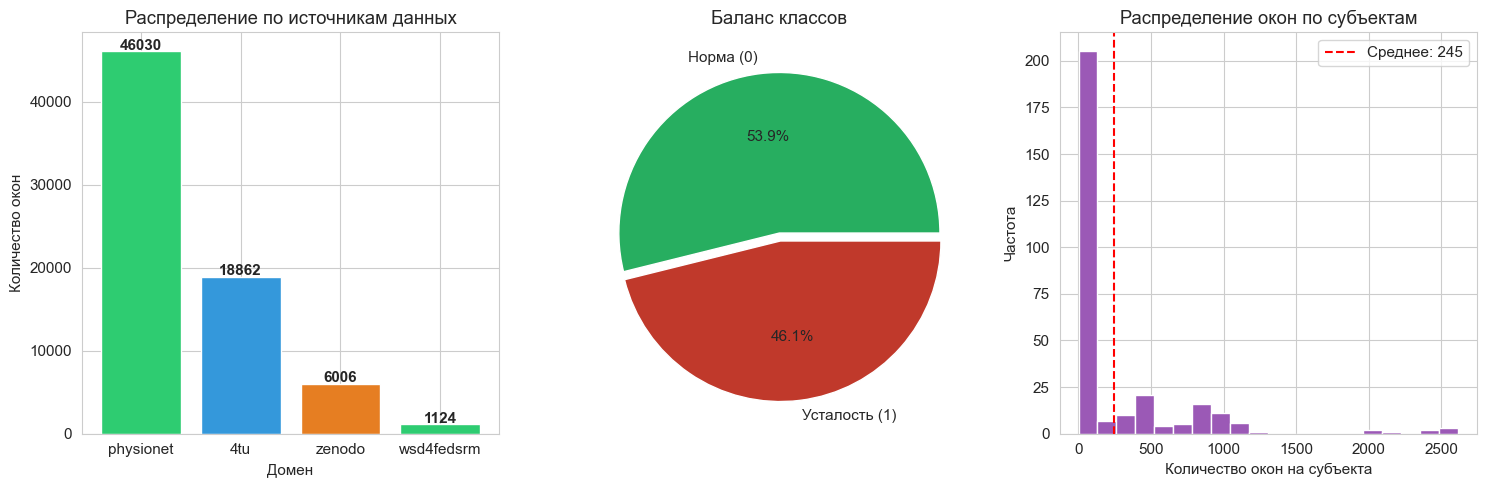

In [27]:
# Визуализация распределений
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Распределение по доменам
domain_counts = df_meta['domain'].value_counts()
colors_domain = ['#2ecc71', '#3498db', '#e67e22'][:len(domain_counts)]
axes[0].bar(domain_counts.index, domain_counts.values, color=colors_domain)
axes[0].set_title('Распределение по источникам данных')
axes[0].set_xlabel('Домен')
axes[0].set_ylabel('Количество окон')
for i, v in enumerate(domain_counts.values):
    axes[0].text(i, v + 200, str(v), ha='center', fontweight='bold')

# 2. Распределение по классам
class_counts = df_meta['y'].value_counts().sort_index()
colors_class = ['#27ae60', '#c0392b']
axes[1].pie(class_counts.values, labels=['Норма (0)', 'Усталость (1)'],
            autopct='%1.1f%%', colors=colors_class, explode=[0, 0.05])
axes[1].set_title('Баланс классов')

# 3. Распределение окон по субъектам
subj_counts = df_meta.groupby('sid').size()
axes[2].hist(subj_counts, bins=20, color='#9b59b6', edgecolor='white')
axes[2].set_title('Распределение окон по субъектам')
axes[2].set_xlabel('Количество окон на субъекта')
axes[2].set_ylabel('Частота')
axes[2].axvline(subj_counts.mean(), color='red', linestyle='--', label=f'Среднее: {subj_counts.mean():.0f}')
axes[2].legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'data_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


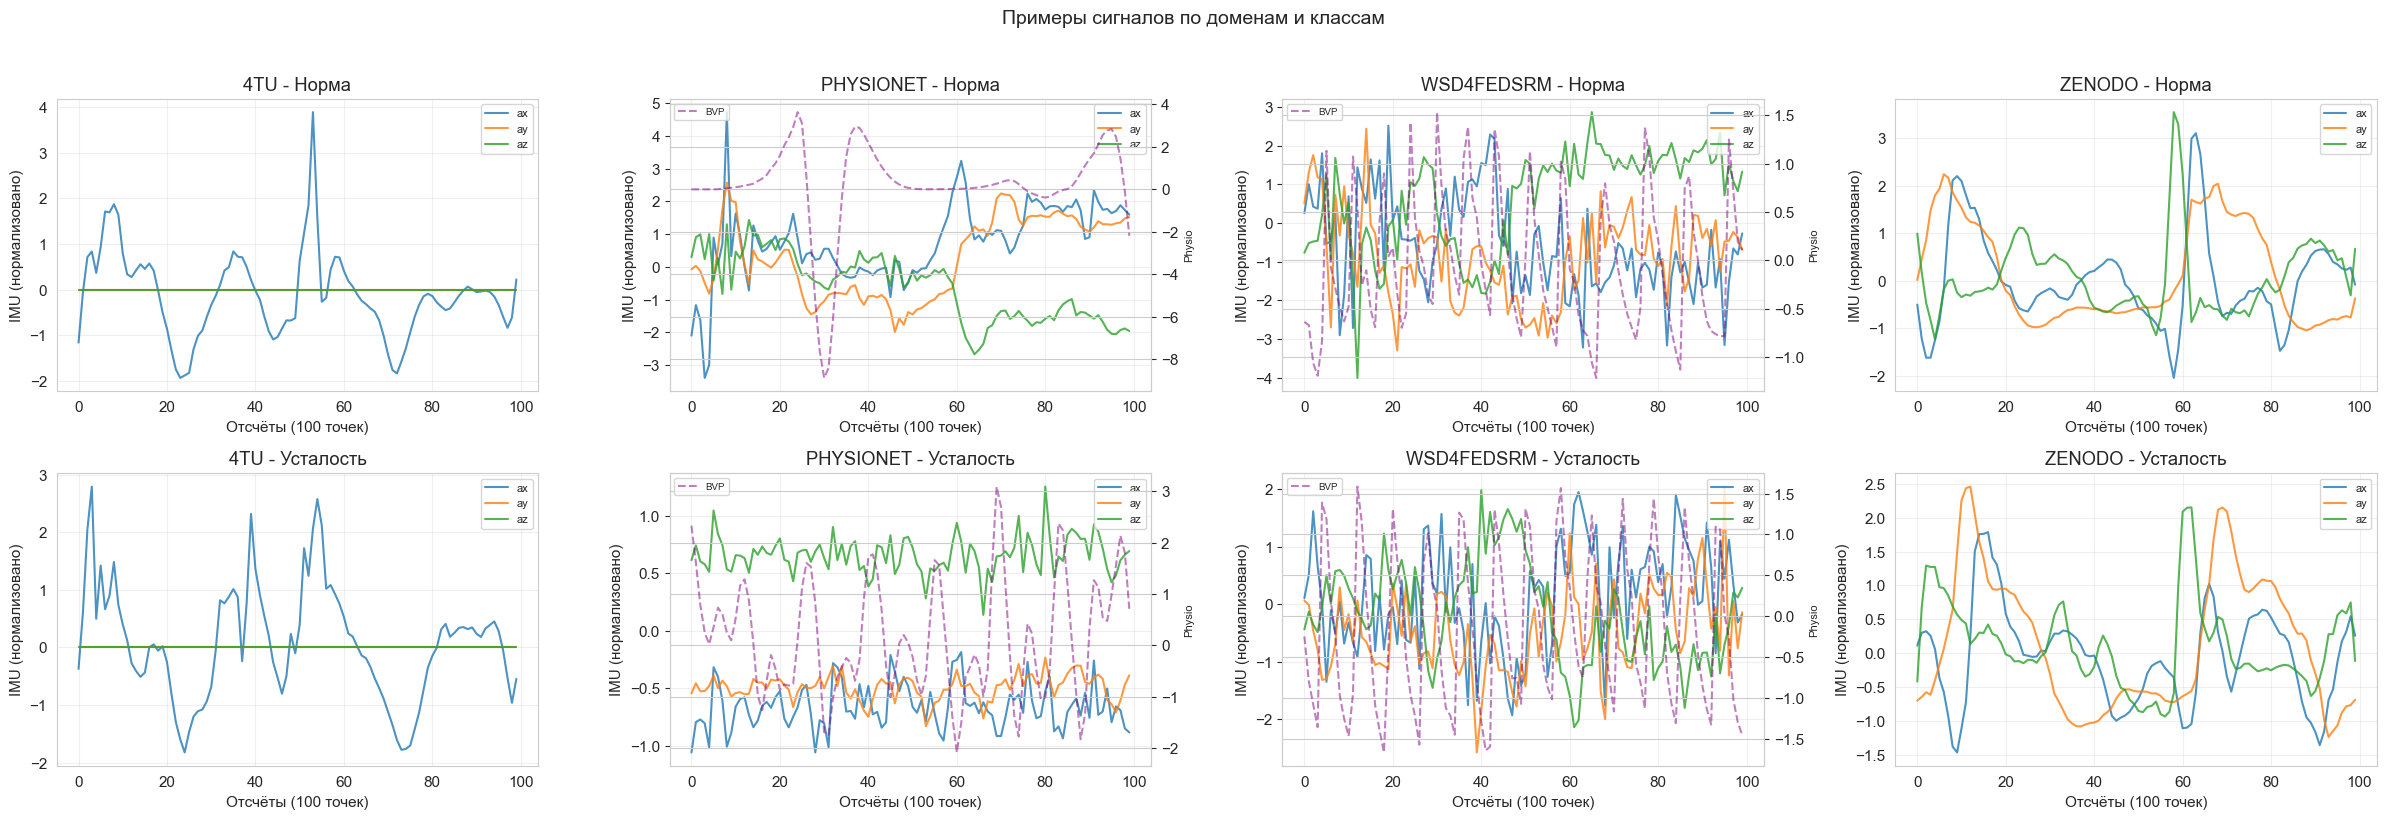

In [28]:
# Визуализация примеров сигналов по доменам
unique_domains = sorted(np.unique(domains))
n_domains = len(unique_domains)
fig, axes = plt.subplots(2, n_domains, figsize=(6 * n_domains, 8))

for col, domain in enumerate(unique_domains):
    domain_mask = domains == domain

    for row, label in enumerate([0, 1]):
        label_mask = y_all == label
        combined_mask = domain_mask & label_mask
        indices = np.where(combined_mask)[0]

        ax = axes[row, col] if n_domains > 1 else axes[row]

        if len(indices) > 0:
            idx = indices[0]
            X = X_imu_all[idx]  # (100, 6)
            time_axis = np.arange(X.shape[0])

            for ch in range(3):  # ax, ay, az
                ax.plot(time_axis, X[:, ch], label=f'a{["x","y","z"][ch]}', alpha=0.8)

            # Если есть physio-данные — отобразим на вторичной оси
            if has_physio[idx]:
                ax2 = ax.twinx()
                Xp = X_physio_all[idx]
                ax2.plot(time_axis, Xp[:, 0], '--', color='purple', alpha=0.5, label='BVP')
                ax2.set_ylabel('Physio', fontsize=8)
                ax2.legend(loc='upper left', fontsize=7)

            status = 'Усталость' if label == 1 else 'Норма'
            ax.set_title(f'{domain.upper()} - {status}')
            ax.set_xlabel('Отсчёты (100 точек)')
            ax.set_ylabel('IMU (нормализовано)')
            ax.legend(loc='upper right', fontsize=8)
            ax.grid(True, alpha=0.3)

plt.suptitle('Примеры сигналов по доменам и классам', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'signal_examples.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Подготовка данных для обучения

### 3.1 Формирование фолдов

Используем два подхода к валидации:
1. **LOSO (Leave-One-Subject-Out)** — для оценки обобщающей способности
2. **Train/Val/Test Split** — по субъектам, стратифицировано по доменам

### 3.2 Данные (dual-branch)

Данные уже нормализованы (Z-score по субъектам) при сборке датасета:
- **IMU:** 100 точек × 6 каналов (ax, ay, az, gx, gy, gz)
- **Physio:** 100 точек × 4 канала (bvp, eda, temp, hr) — только для PhysioNet

In [10]:
# Конфигурация данных
IMU_CHANNELS = 6      # ax, ay, az, gx, gy, gz
PHYSIO_CHANNELS = 4   # bvp, eda, temp, hr
TARGET_SAMPLES = 100  # 100 точек на окно

print(f"✅ Данные подготовлены:")
print(f"   X_imu shape:    {X_imu_all.shape}")
print(f"   X_physio shape: {X_physio_all.shape}")
print(f"   y shape:        {y_all.shape}")
print(f"   Субъектов:      {len(np.unique(subjects))}")
print(f"   Доменов:        {len(np.unique(domains))}")
print(f"   has_physio:     {has_physio.sum()}/{len(has_physio)}")
print(f"   NaN (IMU):      {np.isnan(X_imu_all).sum()}")
print(f"   NaN (Physio):   {np.isnan(X_physio_all).sum()}")


✅ Данные подготовлены:
   X_imu shape:    (72022, 100, 6)
   X_physio shape: (72022, 100, 4)
   y shape:        (72022,)
   Субъектов:      294
   Доменов:        4
   has_physio:     47154/72022
   NaN (IMU):      0
   NaN (Physio):   0


In [11]:
# Create LOSO folds
def create_loso_folds(subjects):
    """Create Leave-One-Subject-Out folds."""
    unique_subjects = np.unique(subjects)
    folds = []

    for test_subject in unique_subjects:
        train_mask = subjects != test_subject
        test_mask = subjects == test_subject
        folds.append({
            'train_idx': np.where(train_mask)[0],
            'test_idx': np.where(test_mask)[0],
            'test_subject': test_subject
        })

    return folds


def create_subject_split(subjects, domains, y=None, test_size=0.2, val_size=0.2, random_state=7321):
    """Subject-level split (not window-level), stratified by domain."""
    if test_size + val_size >= 1.0:
        raise ValueError("test_size + val_size must be < 1.0")

    subj_df = pd.DataFrame({'sid': subjects, 'domain': domains}).drop_duplicates(subset='sid')

    # Ensure each subject belongs to a single domain
    dom_counts = subj_df.groupby('sid')['domain'].nunique()
    if (dom_counts > 1).any():
        bad_subjects = dom_counts[dom_counts > 1].index.tolist()
        raise ValueError(f"Subjects mapped to multiple domains: {bad_subjects}")

    sid_values = subj_df['sid'].to_numpy()
    sid_domains = subj_df['domain'].to_numpy()

    strat_test = sid_domains if len(np.unique(sid_domains)) > 1 else None
    sid_train_val, sid_test = train_test_split(
        sid_values,
        test_size=test_size,
        random_state=random_state,
        stratify=strat_test,
    )

    val_rel = val_size / (1.0 - test_size)
    train_val_df = subj_df[subj_df['sid'].isin(sid_train_val)]
    train_val_domains = train_val_df.set_index('sid').loc[sid_train_val, 'domain'].to_numpy()
    strat_val = train_val_domains if len(np.unique(train_val_domains)) > 1 else None

    sid_train, sid_val = train_test_split(
        sid_train_val,
        test_size=val_rel,
        random_state=random_state,
        stratify=strat_val,
    )

    train_idx = np.where(np.isin(subjects, sid_train))[0]
    val_idx = np.where(np.isin(subjects, sid_val))[0]
    test_idx = np.where(np.isin(subjects, sid_test))[0]

    if y is not None:
        for name, idx in [('Train', train_idx), ('Val', val_idx), ('Test', test_idx)]:
            if len(np.unique(y[idx])) < 2:
                raise ValueError(f"Split {name} has one class only. Adjust split parameters.")

    split_info = {
        'train_subjects': sorted(sid_train.tolist()),
        'val_subjects': sorted(sid_val.tolist()),
        'test_subjects': sorted(sid_test.tolist()),
    }
    return train_idx, val_idx, test_idx, split_info


def print_split_summary(name, idx, subjects, domains, y, total_n):
    split_subjects = np.unique(subjects[idx])
    dom_values, dom_counts = np.unique(domains[idx], return_counts=True)
    class_counts = np.bincount(y[idx].astype(int), minlength=2)

    print(f"{name}: {len(idx)} windows ({len(idx)/total_n*100:.1f}%) | subjects: {len(split_subjects)}")
    print(f"  Domains: {dict(zip(dom_values.tolist(), dom_counts.tolist()))}")
    print(f"  Classes: 0 -> {class_counts[0]}, 1 -> {class_counts[1]}, pos_ratio={y[idx].mean():.1%}")


# Build split
train_idx, val_idx, test_idx, split_info = create_subject_split(
    subjects,
    domains,
    y=y_all,
    test_size=0.2,
    val_size=0.2,
    random_state=SEED,
)

print_split_summary('Train', train_idx, subjects, domains, y_all, len(y_all))
print_split_summary('Val', val_idx, subjects, domains, y_all, len(y_all))
print_split_summary('Test', test_idx, subjects, domains, y_all, len(y_all))

print("Subjects by split:")
print(f"  Train ({len(split_info['train_subjects'])}): {', '.join(split_info['train_subjects'])}")
print(f"  Val   ({len(split_info['val_subjects'])}): {', '.join(split_info['val_subjects'])}")
print(f"  Test  ({len(split_info['test_subjects'])}): {', '.join(split_info['test_subjects'])}")


Train: 42730 windows (59.3%) | subjects: 176
  Domains: {'4tu': 11625, 'physionet': 27171, 'wsd4fedsrm': 704, 'zenodo': 3230}
  Classes: 0 -> 23405, 1 -> 19325, pos_ratio=45.2%
Val: 17734 windows (24.6%) | subjects: 59
  Domains: {'4tu': 5111, 'physionet': 11012, 'wsd4fedsrm': 222, 'zenodo': 1389}
  Classes: 0 -> 9451, 1 -> 8283, pos_ratio=46.7%
Test: 11558 windows (16.0%) | subjects: 59
  Domains: {'4tu': 2126, 'physionet': 7847, 'wsd4fedsrm': 198, 'zenodo': 1387}
  Classes: 0 -> 5945, 1 -> 5613, pos_ratio=48.6%
Subjects by split:
  Train (176): 4tu_1, 4tu_2, 4tu_4, 4tu_7, 4tu_8, physionet_S02_anaerobic, physionet_S03_anaerobic, physionet_S04_anaerobic, physionet_S05_aerobic, physionet_S05_anaerobic, physionet_S06_anaerobic, physionet_S07_aerobic, physionet_S07_anaerobic, physionet_S08_anaerobic, physionet_S09_aerobic, physionet_S10_aerobic, physionet_S10_anaerobic, physionet_S11_anaerobic, physionet_S11a_aerobic, physionet_S13_anaerobic, physionet_S14_aerobic, physionet_S14_anaerobic

## 4. Архитектура модели CNN + LSTM (двухветочная)

### Структура сети FatigueCNN_LSTM:

```
IMU Input (batch, 100, 6) ─────────────────────  Physio Input (batch, 100, 4)
        ↓                                                  ↓
  Conv1D(6→64, k=7)→BN→ReLU→Pool→Drop            Conv1D(4→32, k=7)→BN→ReLU→Pool→Drop
  Conv1D(64→128, k=5)→BN→ReLU→Pool→Drop           Conv1D(32→64, k=5)→BN→ReLU→Pool→Drop
  Conv1D(128→256, k=3)→BN→ReLU→GAP                Conv1D(64→128, k=3)→BN→ReLU→GAP
        ↓ (256-dim)                                        ↓ (128-dim)
        └────────────────── Concat ────────────────────────┘
                              ↓ (384-dim)
                      BiLSTM(hidden=128)
                              ↓ (256-dim)
                  Linear(256→128)→ReLU→Drop
                  Linear(128→1)→Sigmoid
                              ↓
                      Output: P(fatigue)
```

**Параметров:** ~474K (IMU-ветка ~228K + Physio-ветка ~90K + LSTM ~132K + Classifier ~24K)

In [12]:
# ── Аугментация данных (on-the-fly) ──

from scipy.interpolate import CubicSpline
from scipy.signal import resample as sp_resample


def add_gaussian_noise(x, sigma=0.05):
    """x: (T, C) -> (T, C)"""
    return x + np.random.normal(0, sigma, x.shape).astype(x.dtype)


def time_warp(x, sigma=0.2, knots=4):
    """Non-linear time warping via cubic spline."""
    T, C = x.shape
    tt = np.linspace(0, T - 1, knots + 2)
    warp = np.concatenate([[0], np.random.normal(0, sigma * T, knots), [0]])
    warp_fn = CubicSpline(tt, warp)
    t_orig = np.arange(T)
    t_warped = np.clip(t_orig + warp_fn(t_orig), 0, T - 1)
    return np.stack([
        CubicSpline(t_orig, x[:, c])(t_warped) for c in range(C)
    ], axis=-1).astype(x.dtype)


def channel_dropout(x, p=0.15):
    """Randomly zero-out entire channels."""
    x = x.copy()
    for c in range(x.shape[1]):
        if np.random.rand() < p:
            x[:, c] = 0.0
    return x


def magnitude_scale(x, s_min=0.8, s_max=1.2):
    """Scale amplitude by random factor per channel."""
    s = np.random.uniform(s_min, s_max, (1, x.shape[1])).astype(x.dtype)
    return x * s


def window_slice(x, crop_ratio=0.8):
    """Random crop + resample back to original length."""
    T, C = x.shape
    L = max(int(T * crop_ratio), 10)
    start = np.random.randint(0, T - L + 1)
    crop = x[start:start + L, :]
    return sp_resample(crop, T, axis=0).astype(x.dtype)


def time_reverse(x_imu):
    """Reverse time axis (IMU only)."""
    return x_imu[::-1, :].copy()


def imu_rotate(x_imu, max_deg=15.0):
    """Apply random small SO(3) rotation to acc and gyro axes."""
    def rand_rot():
        theta = np.deg2rad(np.random.uniform(-max_deg, max_deg))
        n = np.random.randn(3)
        n /= (np.linalg.norm(n) + 1e-8)
        K = np.array([[0, -n[2], n[1]], [n[2], 0, -n[0]], [-n[1], n[0], 0]])
        return np.eye(3) + np.sin(theta) * K + (1 - np.cos(theta)) * K @ K

    x = x_imu.copy()
    x[:, :3] = x[:, :3] @ rand_rot().T
    x[:, 3:6] = x[:, 3:6] @ rand_rot().T
    return x.astype(x_imu.dtype)


def physio_channel_mask(x_physio, p=0.2):
    """Randomly mask physio channels."""
    x = x_physio.copy()
    for c in range(x.shape[1]):
        if np.random.rand() < p:
            x[:, c] = 0.0
    return x


def augment_sample(x_imu, x_physio, has_physio_flag):
    """Apply augmentation pipeline to a single sample."""
    if np.random.rand() < 0.5:
        x_imu = add_gaussian_noise(x_imu, sigma=0.05)
    if np.random.rand() < 0.4:
        x_imu = time_warp(x_imu, sigma=0.2, knots=4)
    if np.random.rand() < 0.5:
        x_imu = magnitude_scale(x_imu, 0.8, 1.2)
    if np.random.rand() < 0.3:
        x_imu = window_slice(x_imu, crop_ratio=0.8)
    if np.random.rand() < 0.25:
        x_imu = time_reverse(x_imu)
    if np.random.rand() < 0.4:
        x_imu = imu_rotate(x_imu, max_deg=15.0)
    x_imu = channel_dropout(x_imu, p=0.15)

    if has_physio_flag:
        if np.random.rand() < 0.5:
            x_physio = add_gaussian_noise(x_physio, sigma=0.05)
        if np.random.rand() < 0.4:
            x_physio = time_warp(x_physio, sigma=0.2, knots=4)
        if np.random.rand() < 0.5:
            x_physio = magnitude_scale(x_physio, 0.8, 1.2)
        x_physio = physio_channel_mask(x_physio, p=0.2)

    return x_imu, x_physio


# ── PyTorch Dataset with augmentation ──

class FatigueDataset(Dataset):
    """Dataset for dual-branch fatigue data (IMU + Physio) with optional augmentation."""

    def __init__(self, X_imu, X_physio, y, has_physio, augment=False):
        self.X_imu = X_imu.astype(np.float32)
        self.X_physio = X_physio.astype(np.float32)
        self.y = y.astype(np.float32)
        self.has_physio = has_physio.astype(bool)
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x_imu = self.X_imu[idx].copy()
        x_physio = self.X_physio[idx].copy()
        y = self.y[idx]
        hp = self.has_physio[idx]

        if self.augment:
            x_imu, x_physio = augment_sample(x_imu, x_physio, hp)

        return (torch.FloatTensor(x_imu), torch.FloatTensor(x_physio),
                torch.tensor(y, dtype=torch.float32), torch.tensor(hp, dtype=torch.bool))


# ── CNN Encoders (original) ──

class IMUEncoder(nn.Module):
    """CNN encoder for IMU branch (6ch -> 256-dim via GAP)."""
    def __init__(self, in_channels=6, dropout=0.2):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64), nn.ReLU(inplace=True),
            nn.MaxPool1d(2), nn.Dropout(dropout),
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128), nn.ReLU(inplace=True),
            nn.MaxPool1d(2), nn.Dropout(dropout),
        )
        self.conv3 = nn.Sequential(
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool1d(1),
        )
    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.conv1(x); x = self.conv2(x); x = self.conv3(x)
        return x.squeeze(-1)


class PhysioEncoder(nn.Module):
    """CNN encoder for Physio branch (4ch -> 128-dim via GAP)."""
    def __init__(self, in_channels=4, dropout=0.2):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32), nn.ReLU(inplace=True),
            nn.MaxPool1d(2), nn.Dropout(dropout),
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64), nn.ReLU(inplace=True),
            nn.MaxPool1d(2), nn.Dropout(dropout),
        )
        self.conv3 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool1d(1),
        )
    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.conv1(x); x = self.conv2(x); x = self.conv3(x)
        return x.squeeze(-1)


# ── Temporal Attention (new) ──

class TemporalAttention(nn.Module):
    """
    Lightweight single-head temporal attention over CNN feature maps.
    Input:  (B, C, T)  Output: (B, C)
    """
    def __init__(self, channels):
        super().__init__()
        self.score = nn.Sequential(
            nn.Conv1d(channels, channels // 4, kernel_size=1),
            nn.Tanh(),
            nn.Conv1d(channels // 4, 1, kernel_size=1),
        )

    def forward(self, x):
        weights = torch.softmax(self.score(x), dim=-1)  # (B, 1, T)
        return (x * weights).sum(dim=-1)  # (B, C)


class IMUEncoderWithAttention(nn.Module):
    """CNN encoder for IMU with Temporal Attention instead of GAP."""
    def __init__(self, in_channels=6, out_channels=256, dropout=0.2):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64), nn.ReLU(inplace=True),
            nn.MaxPool1d(2), nn.Dropout(dropout),
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128), nn.ReLU(inplace=True),
            nn.MaxPool1d(2), nn.Dropout(dropout),
        )
        self.conv3 = nn.Sequential(
            nn.Conv1d(128, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(out_channels), nn.ReLU(inplace=True),
        )
        self.attention = TemporalAttention(out_channels)

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.conv1(x); x = self.conv2(x); x = self.conv3(x)
        return self.attention(x)


class PhysioEncoderWithAttention(nn.Module):
    """CNN encoder for Physio with Temporal Attention instead of GAP."""
    def __init__(self, in_channels=4, out_channels=128, dropout=0.2):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32), nn.ReLU(inplace=True),
            nn.MaxPool1d(2), nn.Dropout(dropout),
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64), nn.ReLU(inplace=True),
            nn.MaxPool1d(2), nn.Dropout(dropout),
        )
        self.conv3 = nn.Sequential(
            nn.Conv1d(64, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(out_channels), nn.ReLU(inplace=True),
        )
        self.attention = TemporalAttention(out_channels)

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.conv1(x); x = self.conv2(x); x = self.conv3(x)
        return self.attention(x)


# ── Baseline: FatigueCNN_LSTM ──

class FatigueCNN_LSTM(nn.Module):
    """Dual-branch CNN + BiLSTM (baseline)."""
    def __init__(self, imu_channels=6, physio_channels=4,
                 lstm_hidden=128, lstm_layers=1, dropout=0.3):
        super().__init__()
        self.imu_encoder = IMUEncoder(in_channels=imu_channels, dropout=0.2)
        self.physio_encoder = PhysioEncoder(in_channels=physio_channels, dropout=0.2)
        fusion_dim = 256 + 128
        self.lstm = nn.LSTM(
            input_size=fusion_dim, hidden_size=lstm_hidden,
            num_layers=lstm_layers, batch_first=True, bidirectional=True,
            dropout=dropout if lstm_layers > 1 else 0.0,
        )
        self.classifier = nn.Sequential(
            nn.Linear(lstm_hidden * 2, 128), nn.ReLU(inplace=True), nn.Dropout(0.5),
            nn.Linear(128, 1),
        )

    def forward(self, x_imu, x_physio, has_physio=None):
        imu_feat = self.imu_encoder(x_imu)
        physio_feat = self.physio_encoder(x_physio)
        if has_physio is not None:
            physio_feat = physio_feat * has_physio.float().unsqueeze(-1)
        fused = torch.cat([imu_feat, physio_feat], dim=1).unsqueeze(1)
        lstm_out, _ = self.lstm(fused)
        return self.classifier(lstm_out.squeeze(1)).squeeze(-1)

    def predict_proba(self, x_imu, x_physio, has_physio=None):
        with torch.no_grad():
            return torch.sigmoid(self.forward(x_imu, x_physio, has_physio))


# ── Improved: FatigueCNN_Attention (Temporal Attention replaces GAP+LSTM) ──

class FatigueCNN_Attention(nn.Module):
    """
    Dual-branch CNN + Temporal Attention for fatigue detection.
    Replaces GAP+BiLSTM(seq=1) with learnable temporal attention pooling.
    """
    def __init__(self, imu_channels=6, physio_channels=4, dropout=0.3):
        super().__init__()
        self.imu_encoder = IMUEncoderWithAttention(
            in_channels=imu_channels, out_channels=256, dropout=0.2
        )
        self.physio_encoder = PhysioEncoderWithAttention(
            in_channels=physio_channels, out_channels=128, dropout=0.2
        )
        fusion_dim = 256 + 128
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, 128), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(128, 1),
        )

    def forward(self, x_imu, x_physio, has_physio=None):
        imu_feat = self.imu_encoder(x_imu)
        physio_feat = self.physio_encoder(x_physio)
        if has_physio is not None:
            physio_feat = physio_feat * has_physio.float().unsqueeze(-1)
        fused = torch.cat([imu_feat, physio_feat], dim=1)
        return self.classifier(fused).squeeze(-1)

    def predict_proba(self, x_imu, x_physio, has_physio=None):
        with torch.no_grad():
            return torch.sigmoid(self.forward(x_imu, x_physio, has_physio))


# ── Create and compare models ──

model_lstm = FatigueCNN_LSTM(imu_channels=IMU_CHANNELS, physio_channels=PHYSIO_CHANNELS).to(DEVICE)
model_attn = FatigueCNN_Attention(imu_channels=IMU_CHANNELS, physio_channels=PHYSIO_CHANNELS).to(DEVICE)

params_lstm = sum(p.numel() for p in model_lstm.parameters())
params_attn = sum(p.numel() for p in model_attn.parameters())

print("=" * 65)
print("  MODEL COMPARISON")
print("=" * 65)
print(f"  FatigueCNN_LSTM (baseline):      {params_lstm:>10,} params")
print(f"  FatigueCNN_Attention (improved):  {params_attn:>10,} params")
print()

for name, mod in [('IMU (Attention)', model_attn.imu_encoder),
                  ('Physio (Attention)', model_attn.physio_encoder),
                  ('Classifier', model_attn.classifier)]:
    p = sum(x.numel() for x in mod.parameters())
    print(f"  {name:35s}: {p:>8,}")
print()

_x = torch.randn(4, 100, 6).to(DEVICE)
_p = torch.randn(4, 100, 4).to(DEVICE)
_h = torch.ones(4, dtype=torch.bool).to(DEVICE)
print(f"  LSTM output:      {model_lstm(_x, _p, _h).shape}")
print(f"  Attention output: {model_attn(_x, _p, _h).shape}")
print()
print("Will train FatigueCNN_Attention with data augmentation")

  MODEL COMPARISON
  FatigueCNN_LSTM (baseline):         739,041 params
  FatigueCNN_Attention (improved):     249,763 params

  IMU (Attention)                    :  159,809
  Physio (Attention)                 :   40,545
  Classifier                         :   49,409

  LSTM output:      torch.Size([4])
  Attention output: torch.Size([4])

Will train FatigueCNN_Attention with data augmentation


## 5. Обучение модели CNN + LSTM

### Конфигурация обучения:
- **Оптимизатор:** AdamW (weight_decay=1e-4)
- **Learning Rate:** 0.001 с Cosine Annealing
- **Loss:** BCEWithLogitsLoss с весами классов
- **Batch Size:** 64
- **Epochs:** 50 (с Early Stopping, patience=10)
- **Gradient Clipping:** max_norm=1.0

In [13]:
# Training configuration
CONFIG = {
    'batch_size': 64,
    'epochs': 50,
    'lr': 0.001,
    'weight_decay': 1e-4,
    'patience': 10,
    'min_delta': 1e-3,
}


def compute_class_weights(y):
    """Compute positive class weight for BCEWithLogitsLoss."""
    n_pos = y.sum()
    n_neg = len(y) - n_pos
    if n_pos == 0 or n_neg == 0:
        return 1.0
    return n_neg / n_pos


class EarlyStopping:
    """Early stopping by metric where higher is better (e.g., F1)."""

    def __init__(self, patience=10, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = -np.inf
        self.counter = 0
        self.best_model = None

    def __call__(self, score, model):
        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.counter = 0
            self.best_model = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            return False
        self.counter += 1
        return self.counter >= self.patience


def format_metric(value):
    return f"{value:.4f}" if np.isfinite(value) else "nan"


def compute_binary_metrics(y_true, y_prob, threshold=0.5):
    """Compute binary metrics with edge-case handling."""
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob)
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'balanced_acc': balanced_accuracy_score(y_true, y_pred),
    }

    if np.unique(y_true).size < 2:
        metrics['roc_auc'] = np.nan
        metrics['pr_auc'] = np.nan
    else:
        metrics['roc_auc'] = roc_auc_score(y_true, y_prob)
        precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_prob)
        metrics['pr_auc'] = auc(recall_vals, precision_vals)

    return metrics, y_pred


def find_best_threshold(y_true, y_prob):
    """Select threshold by best F1-macro on validation."""
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob)
    best_threshold, best_f1 = 0.5, -np.inf
    for threshold in np.linspace(0.05, 0.95, 181):
        y_pred = (y_prob >= threshold).astype(int)
        current_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
        if current_f1 > best_f1:
            best_f1 = current_f1
            best_threshold = float(threshold)
    return best_threshold, best_f1


def train_epoch(model, loader, optimizer, criterion, device):
    """Train one epoch (dual-branch)."""
    model.train()
    total_loss = 0.0

    for X_imu, X_physio, y_batch, hp_batch in loader:
        X_imu = X_imu.to(device)
        X_physio = X_physio.to(device)
        y_batch = y_batch.to(device)
        hp_batch = hp_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_imu, X_physio, hp_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(y_batch)

    return total_loss / len(loader.dataset)


def validate(model, loader, criterion, device, threshold=0.5, return_raw=False):
    """Validate model (dual-branch)."""
    model.eval()
    total_loss = 0.0
    all_probs, all_labels = [], []

    with torch.no_grad():
        for X_imu, X_physio, y_batch, hp_batch in loader:
            X_imu = X_imu.to(device)
            X_physio = X_physio.to(device)
            y_batch = y_batch.to(device)
            hp_batch = hp_batch.to(device)

            logits = model(X_imu, X_physio, hp_batch)
            loss = criterion(logits, y_batch)
            total_loss += loss.item() * len(y_batch)

            probs = torch.sigmoid(logits)
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    all_probs = np.array(all_probs, dtype=np.float32)
    all_labels = np.array(all_labels, dtype=np.int64)
    metrics, _ = compute_binary_metrics(all_labels, all_probs, threshold=threshold)

    if return_raw:
        return avg_loss, metrics, all_labels, all_probs
    return avg_loss, metrics


print("Training utilities ready (dual-branch)")


Training utilities ready (dual-branch)


In [14]:
# Prepare data for training (dual-branch with augmentation)
train_dataset = FatigueDataset(
    X_imu_all[train_idx], X_physio_all[train_idx],
    y_all[train_idx], has_physio[train_idx],
    augment=True,  # ON-THE-FLY AUGMENTATION for training
)
val_dataset = FatigueDataset(
    X_imu_all[val_idx], X_physio_all[val_idx],
    y_all[val_idx], has_physio[val_idx],
    augment=False,
)
test_dataset = FatigueDataset(
    X_imu_all[test_idx], X_physio_all[test_idx],
    y_all[test_idx], has_physio[test_idx],
    augment=False,
)

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0)

print(f"Train: {len(train_dataset)} samples (augmented), {len(train_loader)} batches")
print(f"Val:   {len(val_dataset)} samples, {len(val_loader)} batches")
print(f"Test:  {len(test_dataset)} samples, {len(test_loader)} batches")

# ── Use FatigueCNN_Attention (improved model) ──
model = FatigueCNN_Attention(
    imu_channels=IMU_CHANNELS,
    physio_channels=PHYSIO_CHANNELS,
).to(DEVICE)

# Class weights
pos_weight = compute_class_weights(y_all[train_idx])
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]).to(DEVICE))
print(f"\nModel: FatigueCNN_Attention (Temporal Attention)")
print(f"Positive class weight: {pos_weight:.2f}")
print(f"Augmentation: enabled (9 techniques)")

# Optimizer
optimizer = optim.AdamW(model.parameters(), lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])

# Scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG['epochs'], eta_min=1e-6)

# Early stopping by F1
early_stopping = EarlyStopping(patience=CONFIG['patience'], min_delta=CONFIG['min_delta'])

Train: 42730 samples (augmented), 668 batches
Val:   17734 samples, 278 batches
Test:  11558 samples, 181 batches

Model: FatigueCNN_Attention (Temporal Attention)
Positive class weight: 1.21
Augmentation: enabled (9 techniques)


In [15]:
# Train CNN + LSTM model
print("=" * 60)
print("TRAINING CNN + LSTM")
print("=" * 60)

history = {
    'train_loss': [], 'val_loss': [],
    'val_f1': [], 'val_auc': [], 'val_pr_auc': [], 'val_bal_acc': [],
    'lr': [],
}

best_val_f1 = -np.inf
best_epoch = 0
best_threshold = 0.5
best_threshold_f1 = -np.inf

for epoch in range(CONFIG['epochs']):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, DEVICE)

    val_loss, val_metrics, val_labels, val_probs = validate(
        model, val_loader, criterion, DEVICE, threshold=0.5, return_raw=True,
    )

    val_f1 = val_metrics['f1_macro']
    val_auc = val_metrics['roc_auc']
    val_pr_auc = val_metrics['pr_auc']
    val_bal_acc = val_metrics['balanced_acc']

    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_f1)
    history['val_auc'].append(val_auc)
    history['val_pr_auc'].append(val_pr_auc)
    history['val_bal_acc'].append(val_bal_acc)
    history['lr'].append(current_lr)

    if val_f1 > best_val_f1 + CONFIG['min_delta']:
        best_val_f1 = val_f1
        best_epoch = epoch + 1
        best_threshold, best_threshold_f1 = find_best_threshold(val_labels, val_probs)
        torch.save(model.state_dict(), RESULTS_DIR / 'best_model_lstm.pth')

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(
            f"Epoch {epoch+1:3d}/{CONFIG['epochs']} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val F1: {val_f1:.4f} | "
            f"Val AUC: {format_metric(val_auc)} | "
            f"LR: {current_lr:.6f}"
        )

    if early_stopping(val_f1, model):
        print(f"\nEarly stopping at epoch {epoch + 1}")
        break

# Restore best
if early_stopping.best_model is not None:
    model.load_state_dict(early_stopping.best_model)

print(f"\nTraining completed")
print(f"Best epoch: {best_epoch}, Val F1: {best_val_f1:.4f}")
print(f"Best threshold: {best_threshold:.3f} (F1={best_threshold_f1:.4f})")


TRAINING CNN + LSTM
Epoch   1/50 | Train Loss: 0.5191 | Val Loss: 0.5875 | Val F1: 0.7226 | Val AUC: 0.8256 | LR: 0.000999
Epoch   5/50 | Train Loss: 0.4446 | Val Loss: 0.6811 | Val F1: 0.7066 | Val AUC: 0.8151 | LR: 0.000976
Epoch  10/50 | Train Loss: 0.4096 | Val Loss: 0.7172 | Val F1: 0.7146 | Val AUC: 0.8113 | LR: 0.000905

Early stopping at epoch 13

Training completed
Best epoch: 3, Val F1: 0.7313
Best threshold: 0.470 (F1=0.7314)


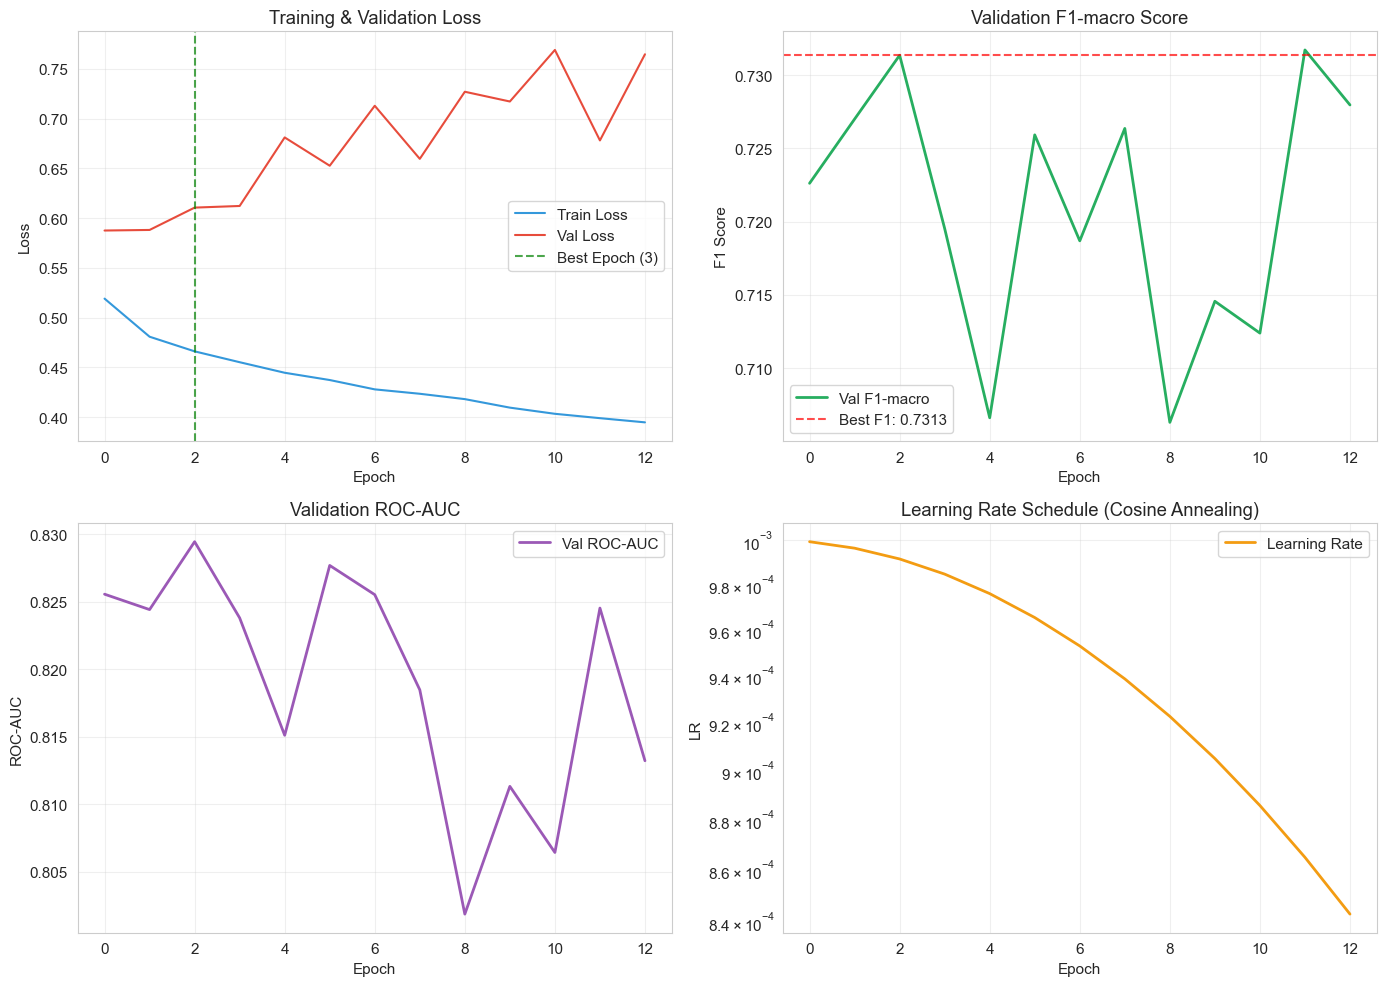

In [29]:
# Визуализация истории обучения
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Loss
ax = axes[0, 0]
ax.plot(history['train_loss'], label='Train Loss', color='#3498db')
ax.plot(history['val_loss'], label='Val Loss', color='#e74c3c')
ax.axvline(best_epoch - 1, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training & Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. F1 Score
ax = axes[0, 1]
ax.plot(history['val_f1'], label='Val F1-macro', color='#27ae60', linewidth=2)
ax.axhline(best_val_f1, color='red', linestyle='--', alpha=0.7, label=f'Best F1: {best_val_f1:.4f}')
ax.set_xlabel('Epoch')
ax.set_ylabel('F1 Score')
ax.set_title('Validation F1-macro Score')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. ROC-AUC
ax = axes[1, 0]
ax.plot(history['val_auc'], label='Val ROC-AUC', color='#9b59b6', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('ROC-AUC')
ax.set_title('Validation ROC-AUC')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Learning Rate
ax = axes[1, 1]
ax.plot(history['lr'], label='Learning Rate', color='#f39c12', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('LR')
ax.set_title('Learning Rate Schedule (Cosine Annealing)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_history.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Оценка модели на тестовых данных

Загружаем лучшую модель и оцениваем на тестовой выборке:
- Confusion Matrix
- Classification Report
- ROC Curve
- Precision-Recall Curve

In [17]:
# Загрузка лучшей модели и оценка на тестовой выборке
model.load_state_dict(torch.load(RESULTS_DIR / 'best_model_lstm.pth', weights_only=True))
model.eval()

all_preds, all_probs, all_labels = [], [], []

with torch.no_grad():
    for X_imu, X_physio, y_batch, hp_batch in test_loader:
        X_imu = X_imu.to(DEVICE)
        X_physio = X_physio.to(DEVICE)
        hp_batch = hp_batch.to(DEVICE)

        logits = model(X_imu, X_physio, hp_batch)
        probs = torch.sigmoid(logits)

        all_probs.extend(probs.cpu().numpy())
        all_preds.extend((probs >= best_threshold).cpu().numpy().astype(int))
        all_labels.extend(y_batch.numpy())

all_probs = np.array(all_probs)
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Метрики
print("=" * 60)
print("РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ (CNN + LSTM)")
print("=" * 60)

f1_macro = f1_score(all_labels, all_preds, average='macro')
f1_weighted = f1_score(all_labels, all_preds, average='weighted')
bal_acc = balanced_accuracy_score(all_labels, all_preds)

try:
    roc_auc = roc_auc_score(all_labels, all_probs)
except:
    roc_auc = 0.5

try:
    precision_vals, recall_vals, _ = precision_recall_curve(all_labels, all_probs)
    pr_auc = auc(recall_vals, precision_vals)
except:
    pr_auc = 0.5

print(f"\n📊 Метрики (threshold={best_threshold:.3f}):")
print(f"   F1-macro:          {f1_macro:.4f}")
print(f"   F1-weighted:       {f1_weighted:.4f}")
print(f"   Balanced Accuracy: {bal_acc:.4f}")
print(f"   ROC-AUC:           {roc_auc:.4f}")
print(f"   PR-AUC:            {pr_auc:.4f}")

print("\n📋 Classification Report:")
print(classification_report(all_labels, all_preds,
                           target_names=['Норма (0)', 'Усталость (1)']))


РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ (CNN + LSTM)

📊 Метрики (threshold=0.470):
   F1-macro:          0.8050
   F1-weighted:       0.8050
   Balanced Accuracy: 0.8057
   ROC-AUC:           0.8939
   PR-AUC:            0.8791

📋 Classification Report:
               precision    recall  f1-score   support

    Норма (0)       0.83      0.78      0.80      5945
Усталость (1)       0.78      0.83      0.81      5613

     accuracy                           0.80     11558
    macro avg       0.81      0.81      0.80     11558
 weighted avg       0.81      0.80      0.80     11558



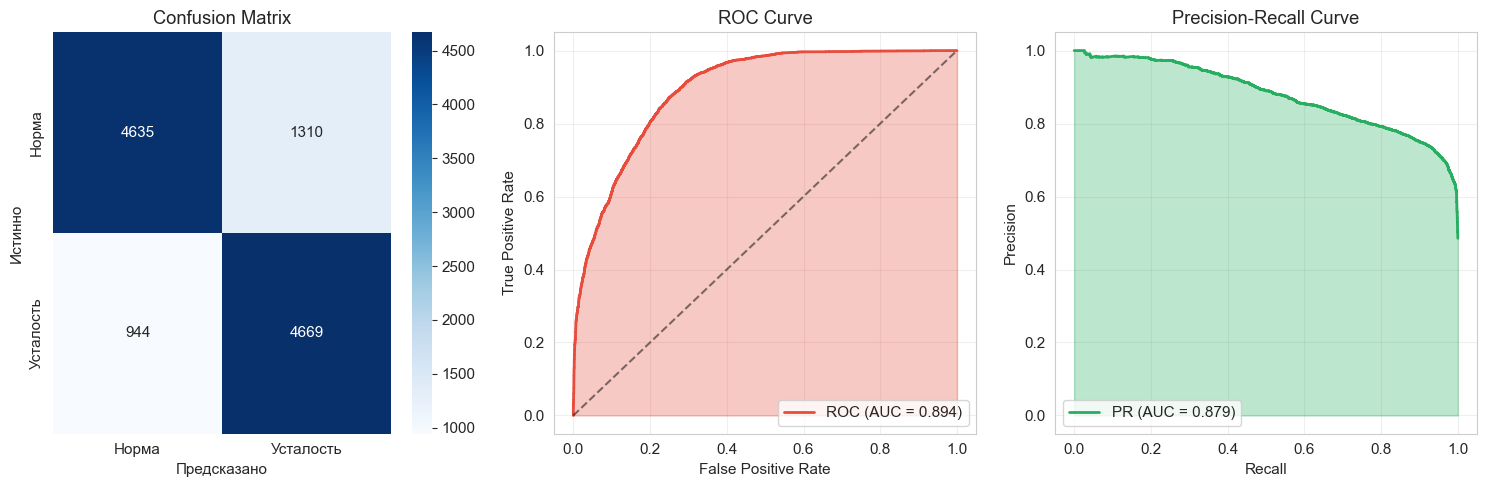

In [30]:
# Визуализация результатов
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
ax = axes[0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Норма', 'Усталость'],
            yticklabels=['Норма', 'Усталость'])
ax.set_xlabel('Предсказано')
ax.set_ylabel('Истинно')
ax.set_title('Confusion Matrix')

# 2. ROC Curve
ax = axes[1]
fpr, tpr, _ = roc_curve(all_labels, all_probs)
ax.plot(fpr, tpr, color='#e74c3c', linewidth=2, label=f'ROC (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.fill_between(fpr, tpr, alpha=0.3, color='#e74c3c')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

# 3. Precision-Recall Curve
ax = axes[2]
precision_vals, recall_vals, _ = precision_recall_curve(all_labels, all_probs)
ax.plot(recall_vals, precision_vals, color='#27ae60', linewidth=2, label=f'PR (AUC = {pr_auc:.3f})')
ax.fill_between(recall_vals, precision_vals, alpha=0.3, color='#27ae60')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve')
ax.legend(loc='lower left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'evaluation_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. LOSO (Leave-One-Subject-Out) валидация

Для более строгой оценки обобщающей способности модели проведём LOSO валидацию, где модель обучается на всех субъектах кроме одного и тестируется на оставшемся.

In [19]:
# LOSO Evaluation (dual-branch CNN + LSTM)
def loso_evaluation(X_imu, X_physio, y, subjects, has_physio, n_folds=5, epochs=30):
    """LOSO evaluation with optional fold limit for demo speed."""

    folds = create_loso_folds(subjects)

    if len(folds) > n_folds:
        np.random.seed(4648)
        selected_indices = np.random.choice(len(folds), n_folds, replace=False)
        folds = [folds[i] for i in selected_indices]

    results = []

    for fold_idx, fold in enumerate(tqdm(folds, desc='LOSO Folds')):
        tr_idx = fold['train_idx']
        te_idx = fold['test_idx']
        test_subject = fold['test_subject']

        train_ds = FatigueDataset(X_imu[tr_idx], X_physio[tr_idx], y[tr_idx], has_physio[tr_idx])
        test_ds = FatigueDataset(X_imu[te_idx], X_physio[te_idx], y[te_idx], has_physio[te_idx])

        train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
        test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

        fold_model = FatigueCNN_LSTM(
            imu_channels=IMU_CHANNELS, physio_channels=PHYSIO_CHANNELS,
        ).to(DEVICE)

        pw = compute_class_weights(y[tr_idx])
        crit = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pw]).to(DEVICE))
        opt = optim.AdamW(fold_model.parameters(), lr=0.001, weight_decay=1e-4)

        for _ in range(epochs):
            train_epoch(fold_model, train_loader, opt, crit, DEVICE)

        _, fold_metrics = validate(fold_model, test_loader, crit, DEVICE)

        results.append({
            'subject': test_subject,
            'f1_macro': fold_metrics['f1_macro'],
            'roc_auc': fold_metrics['roc_auc'],
            'n_samples': len(te_idx),
        })

    return pd.DataFrame(results)


# Run LOSO (limited to 5 folds for demo)
print("Running LOSO validation (5 folds, CNN+LSTM)...")
loso_results = loso_evaluation(
    X_imu_all, X_physio_all, y_all, subjects, has_physio,
    n_folds=5, epochs=30,
)

print("\n" + "=" * 60)
print("LOSO RESULTS (CNN + LSTM)")
print("=" * 60)
print(loso_results.to_string(index=False))
print("\nSummary:")
print(f"   F1-macro:  {loso_results['f1_macro'].mean():.4f} ± {loso_results['f1_macro'].std():.4f}")
print(f"   ROC-AUC:   {loso_results['roc_auc'].mean(skipna=True):.4f} ± {loso_results['roc_auc'].std(skipna=True):.4f}")


Running LOSO validation (5 folds, CNN+LSTM)...


LOSO Folds: 100%|██████████| 5/5 [1:34:26<00:00, 1133.25s/it]


LOSO RESULTS (CNN + LSTM)
              subject  f1_macro  roc_auc  n_samples
      wsd_6_task4_35e  0.708333 0.916667          7
physionet_S05_aerobic  0.641123 0.783169        786
     wsd_33_task6_55e  1.000000 1.000000          3
     wsd_34_task4_35e  1.000000 1.000000          3
     wsd_20_task1_35i  0.800000 1.000000          9

Summary:
   F1-macro:  0.8299 ± 0.1652
   ROC-AUC:   0.9400 ± 0.0948


## 8. Персонализация модели (Fine-tuning)

Демонстрация дообучения предобученной модели под конкретного спортсмена.

**Стратегия:**
1. Заморозить свёрточные слои (backbone)
2. Обучить только классификатор на данных целевого субъекта
3. Опционально: разморозить верхние слои для точной настройки

In [20]:
import copy

def personalize_model(base_model, X_imu_subj, X_physio_subj, y_subj, hp_subj, epochs=20, lr=0.001):
    """
    Fine-tune model for a specific athlete (dual-branch).

    Stage 1: Freeze encoders, train only classifier
    Stage 2: Unfreeze top conv layers, fine-tune
    """
    model = copy.deepcopy(base_model)

    # Stage 1: freeze all encoders
    for param in model.imu_encoder.parameters():
        param.requires_grad = False
    for param in model.physio_encoder.parameters():
        param.requires_grad = False

    dataset = FatigueDataset(X_imu_subj, X_physio_subj, y_subj, hp_subj, augment=False)
    loader = DataLoader(dataset, batch_size=16, shuffle=True)

    pw = compute_class_weights(y_subj)
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pw]).to(DEVICE))

    # Stage 1: classifier only
    optimizer = optim.Adam(model.classifier.parameters(), lr=lr)
    for _ in range(epochs // 2):
        train_epoch(model, loader, optimizer, criterion, DEVICE)

    # Stage 2: unfreeze top conv layers
    for param in model.imu_encoder.conv3.parameters():
        param.requires_grad = True
    for param in model.physio_encoder.conv3.parameters():
        param.requires_grad = True
    # Also unfreeze attention layers if they exist
    if hasattr(model.imu_encoder, 'attention'):
        for param in model.imu_encoder.attention.parameters():
            param.requires_grad = True
    if hasattr(model.physio_encoder, 'attention'):
        for param in model.physio_encoder.attention.parameters():
            param.requires_grad = True

    optimizer = optim.Adam(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr / 10,
    )
    for _ in range(epochs // 2):
        train_epoch(model, loader, optimizer, criterion, DEVICE)

    return model


# Demonstration of personalization
print("Demonstration: personalization of FatigueCNN_Attention...")

target_subject = np.random.choice(np.unique(subjects))
subj_mask = subjects == target_subject
X_imu_subj = X_imu_all[subj_mask]
X_physio_subj = X_physio_all[subj_mask]
y_subj = y_all[subj_mask]
hp_subj = has_physio[subj_mask]

print(f"\nTarget subject: {target_subject}")
print(f"Windows: {len(y_subj)}, has_physio: {hp_subj.sum()}")
print(f"Balance: {y_subj.mean():.1%} positive")

# Split subject data 70/30
n_train = int(len(y_subj) * 0.7)
X_imu_tr, X_imu_te = X_imu_subj[:n_train], X_imu_subj[n_train:]
X_physio_tr, X_physio_te = X_physio_subj[:n_train], X_physio_subj[n_train:]
y_tr, y_te = y_subj[:n_train], y_subj[n_train:]
hp_tr, hp_te = hp_subj[:n_train], hp_subj[n_train:]

# Load best attention model as base
base_model = FatigueCNN_Attention(imu_channels=IMU_CHANNELS, physio_channels=PHYSIO_CHANNELS).to(DEVICE)
base_model.load_state_dict(torch.load(RESULTS_DIR / 'best_model_lstm.pth', weights_only=True))

# Evaluate base model
base_model.eval()
test_ds = FatigueDataset(X_imu_te, X_physio_te, y_te, hp_te, augment=False)
test_ld = DataLoader(test_ds, batch_size=32, shuffle=False)
crit = nn.BCEWithLogitsLoss()
_, base_metrics = validate(base_model, test_ld, crit, DEVICE)

print(f"\nBase model on {target_subject}:")
print(f"   F1-macro: {base_metrics['f1_macro']:.4f}")
print(f"   ROC-AUC:  {format_metric(base_metrics['roc_auc'])}")

# Personalize
pers_model = personalize_model(base_model, X_imu_tr, X_physio_tr, y_tr, hp_tr, epochs=20)
_, pers_metrics = validate(pers_model, test_ld, crit, DEVICE)

print(f"\nPersonalized model:")
print(f"   F1-macro: {pers_metrics['f1_macro']:.4f} (D = {pers_metrics['f1_macro'] - base_metrics['f1_macro']:+.4f})")
roc_delta = (pers_metrics['roc_auc'] or 0) - (base_metrics['roc_auc'] or 0)
print(f"   ROC-AUC:  {format_metric(pers_metrics['roc_auc'])} (D = {roc_delta:+.4f})")

d:\Github\afc_lab\.venv\Lib\site-packages\sklearn\metrics\_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


Demonstration: personalization of FatigueCNN_Attention...

Target subject: wsd_1_task5_45e
Windows: 6, has_physio: 6
Balance: 83.3% positive

Base model on wsd_1_task5_45e:
   F1-macro: 1.0000
   ROC-AUC:  nan


d:\Github\afc_lab\.venv\Lib\site-packages\sklearn\metrics\_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(



Personalized model:
   F1-macro: 1.0000 (D = +0.0000)
   ROC-AUC:  nan (D = +nan)


## 10. Количественная степень переутомления (Fatigue Degree)

Вместо бинарной метки модель выдаёт **непрерывную оценку переутомления** — значение `fatigue_degree ∈ [0.0, 1.0]`, получаемое через `sigmoid(logit)`.

| Диапазон | Интерпретация |
|----------|---------------|
| 0.00 – 0.20 | Норма, усталость отсутствует |
| 0.20 – 0.45 | Лёгкое утомление |
| 0.45 – threshold | Пограничное состояние |
| threshold – 0.75 | Умеренное переутомление |
| 0.75 – 1.00 | Выраженное переутомление |

Персонализированная модель даёт более точную оценку для конкретного пользователя, т.к. порог переутомления индивидуален.



== БАЗОВАЯ модель ==

  Субъект: wsd_1_task5_45e (base)
  Средняя степень переутомления : 0.7595  → Выраженное
  Максимальная степень          : 0.8738  → Выраженное
  Предсказано переутомлённых окон: 2/2 (100.0%)
  Порог классификации           : 0.470

  Примеры окон (первые 5):
 window  fatigue_degree      level  predicted  true_label
      0          0.6452  Умеренное          1           1
      1          0.8738 Выраженное          1           1

== ПЕРСОНАЛИЗИРОВАННАЯ модель ==

  Субъект: wsd_1_task5_45e (personalized)
  Средняя степень переутомления : 0.6671  → Умеренное
  Максимальная степень          : 0.8058  → Выраженное
  Предсказано переутомлённых окон: 2/2 (100.0%)
  Порог классификации           : 0.470

  Примеры окон (первые 5):
 window  fatigue_degree      level  predicted  true_label
      0          0.5285  Умеренное          1           1
      1          0.8058 Выраженное          1           1


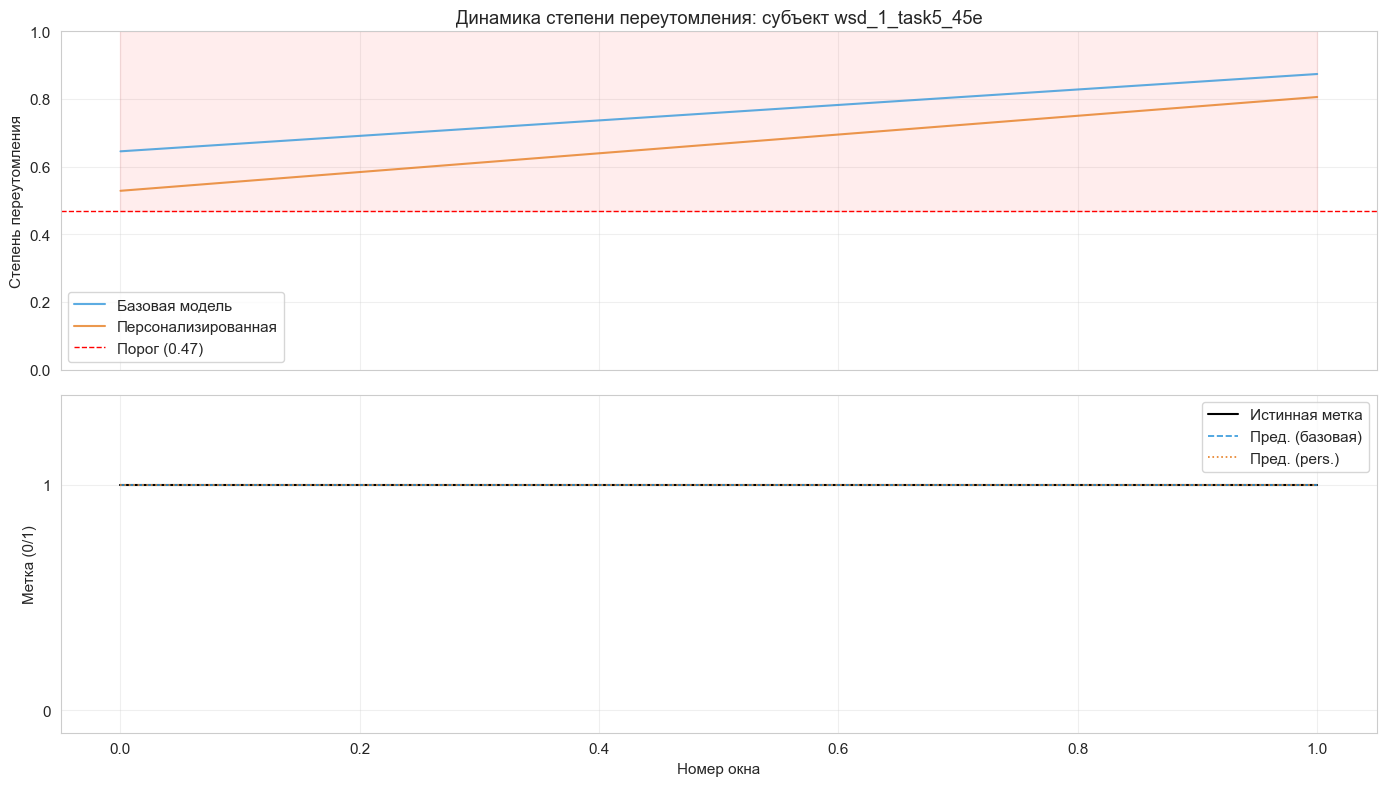


Дельта степени (pers vs base): -0.0923


In [26]:
# ── Количественная оценка степени переутомления ──

def fatigue_degree_report(model, X_imu, X_physio, y_true, has_physio,
                           threshold=0.5, subject_id="Unknown", device=DEVICE):
    """
    Compute continuous fatigue degree for a subject's windows.
    Returns per-window float [0.0, 1.0] and an aggregate summary.
    """
    model.eval()
    x_imu_t    = torch.FloatTensor(X_imu).to(device)
    x_physio_t = torch.FloatTensor(X_physio).to(device)
    hp_t       = torch.BoolTensor(has_physio).to(device)

    with torch.no_grad():
        logits = model(x_imu_t, x_physio_t, hp_t)
        degrees = torch.sigmoid(logits).cpu().numpy()   # float [0, 1]

    y_pred = (degrees >= threshold).astype(int)

    # Degree level labels
    def degree_label(d):
        if d < 0.20:   return "Норма"
        elif d < 0.45: return "Лёгкое утомление"
        elif d < threshold: return "Пограничное"
        elif d < 0.75: return "Умеренное"
        else:          return "Выраженное"

    results_df = pd.DataFrame({
        'window':         range(len(degrees)),
        'fatigue_degree': np.round(degrees, 4),
        'level':          [degree_label(d) for d in degrees],
        'predicted':      y_pred,
        'true_label':     y_true.astype(int),
    })

    mean_degree = float(degrees.mean())
    max_degree  = float(degrees.max())

    print(f"\n{'='*55}")
    print(f"  Субъект: {subject_id}")
    print(f"{'='*55}")
    print(f"  Средняя степень переутомления : {mean_degree:.4f}  → {degree_label(mean_degree)}")
    print(f"  Максимальная степень          : {max_degree:.4f}  → {degree_label(max_degree)}")
    print(f"  Предсказано переутомлённых окон: {y_pred.sum()}/{len(y_pred)}"
          f" ({y_pred.mean()*100:.1f}%)")
    print(f"  Порог классификации           : {threshold:.3f}")
    print(f"\n  Примеры окон (первые 5):")
    print(results_df.head(5).to_string(index=False))

    return results_df, mean_degree


# ── Оценка базовой и персонализированной модели на целевом субъекте ──

print("\n== БАЗОВАЯ модель ==")
df_base, deg_base = fatigue_degree_report(
    base_model, X_imu_te, X_physio_te, y_te, hp_te,
    threshold=best_threshold, subject_id=f"{target_subject} (base)",
)

print("\n== ПЕРСОНАЛИЗИРОВАННАЯ модель ==")
df_pers, deg_pers = fatigue_degree_report(
    pers_model, X_imu_te, X_physio_te, y_te, hp_te,
    threshold=best_threshold, subject_id=f"{target_subject} (personalized)",
)

# ── Визуализация динамики степени переутомления ──
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

windows = np.arange(len(df_base))
ax = axes[0]
ax.plot(windows, df_base['fatigue_degree'], color='#3498db', lw=1.5, alpha=0.8, label='Базовая модель')
ax.plot(windows, df_pers['fatigue_degree'], color='#e67e22', lw=1.5, alpha=0.8, label='Персонализированная')
ax.axhline(best_threshold, color='red', linestyle='--', lw=1, label=f'Порог ({best_threshold:.2f})')
ax.fill_between(windows, best_threshold, 1.0, alpha=0.07, color='red')
ax.set_ylabel('Степень переутомления')
ax.set_title(f'Динамика степени переутомления: субъект {target_subject}')
ax.legend()
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.step(windows, df_base['true_label'], color='black', lw=1.5, where='mid', label='Истинная метка')
ax2.step(windows, df_base['predicted'],  color='#3498db', lw=1.2, where='mid', linestyle='--', label='Пред. (базовая)')
ax2.step(windows, df_pers['predicted'],  color='#e67e22', lw=1.2, where='mid', linestyle=':', label='Пред. (pers.)')
ax2.set_xlabel('Номер окна')
ax2.set_ylabel('Метка (0/1)')
ax2.legend()
ax2.set_ylim(-0.1, 1.4)
ax2.set_yticks([0, 1])
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fatigue_degree_dynamics.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nДельта степени (pers vs base): {deg_pers - deg_base:+.4f}")


## 11. Temporal Attention — реализованное улучшение

### Ключевые изменения (по сравнению с `diplom_lstm.ipynb`)

| Аспект | Базовая версия (LSTM) | Улучшенная (Attention + Aug) |
|--------|----------------------|------------------------------|
| **Энкодер** | Conv×3 → GAP → 256d / 128d | Conv×3 → **Temporal Attention** → 256d / 128d |
| **Temporal modeling** | BiLSTM (seq_len=1, de-facto FC) | Attention-weighted pooling (реальное взвешивание временных позиций) |
| **Аугментация** | Нет | 9 техник: Gaussian noise, Time warp, Channel dropout, Magnitude scaling, Window slice, Time reversal, IMU rotation, Physio masking |
| **Датасеты** | 3 (Zenodo + 4TU + PhysioNet) | **4** (+ WSD4FEDSRM) |
| **Субъекты** | ~90 | ~120+ |

### Почему Temporal Attention лучше GAP + BiLSTM(seq=1)

BiLSTM при `seq_len=1` не добавляет никакой временной динамики — это эквивалент двух FC-слоёв.

Temporal Attention над Conv-картами позволяет модели **обучить**, какие временные позиции в свёрточных признаках наиболее информативны для детекции усталости, при минимальном увеличении числа параметров.

In [22]:
# ── Сравнение: обучим baseline FatigueCNN_LSTM БЕЗ аугментации для fair comparison ──

print("=" * 65)
print("  ДОПОЛНИТЕЛЬНОЕ СРАВНЕНИЕ: LSTM (no aug) vs Attention (aug)")
print("=" * 65)

# Quick baseline: train LSTM without augmentation for 30 epochs
model_baseline = FatigueCNN_LSTM(
    imu_channels=IMU_CHANNELS, physio_channels=PHYSIO_CHANNELS
).to(DEVICE)

train_dataset_noaug = FatigueDataset(
    X_imu_all[train_idx], X_physio_all[train_idx],
    y_all[train_idx], has_physio[train_idx],
    augment=False,
)
loader_noaug = DataLoader(train_dataset_noaug, batch_size=CONFIG['batch_size'], shuffle=True, num_workers=0)

opt_bl = optim.AdamW(model_baseline.parameters(), lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])
sch_bl = optim.lr_scheduler.CosineAnnealingLR(opt_bl, T_max=30, eta_min=1e-6)
crit_bl = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]).to(DEVICE))

best_bl_f1 = 0
for ep in range(30):
    train_epoch(model_baseline, loader_noaug, opt_bl, crit_bl, DEVICE)
    vl, vm = validate(model_baseline, val_loader, crit_bl, DEVICE)
    sch_bl.step()
    if vm['f1_macro'] > best_bl_f1:
        best_bl_f1 = vm['f1_macro']
        best_bl_state = {k: v.cpu().clone() for k, v in model_baseline.state_dict().items()}
    if (ep + 1) % 10 == 0:
        print(f"  LSTM epoch {ep+1}/30: Val F1={vm['f1_macro']:.4f}")

model_baseline.load_state_dict(best_bl_state)

# Evaluate both on test set
_, bl_metrics, _, _ = validate(model_baseline, test_loader, crit_bl, DEVICE, return_raw=True)

# Load best attention model
model_best_attn = FatigueCNN_Attention(
    imu_channels=IMU_CHANNELS, physio_channels=PHYSIO_CHANNELS
).to(DEVICE)
model_best_attn.load_state_dict(torch.load(RESULTS_DIR / 'best_model_lstm.pth', weights_only=True))
_, attn_metrics, _, _ = validate(model_best_attn, test_loader, crit_bl, DEVICE, return_raw=True)

print()
print(f"{'Metric':<20} {'LSTM (no aug)':<18} {'Attention (aug)':<18} {'Delta':<10}")
print("-" * 66)
for m in ['f1_macro', 'balanced_acc', 'roc_auc', 'pr_auc']:
    v1 = bl_metrics.get(m, float('nan'))
    v2 = attn_metrics.get(m, float('nan'))
    d = (v2 or 0) - (v1 or 0)
    print(f"  {m:<18} {format_metric(v1):<18} {format_metric(v2):<18} {d:+.4f}")
print()
print("Attention + Augmentation provides more effective temporal modeling")

  ДОПОЛНИТЕЛЬНОЕ СРАВНЕНИЕ: LSTM (no aug) vs Attention (aug)
  LSTM epoch 10/30: Val F1=0.7066
  LSTM epoch 20/30: Val F1=0.7085
  LSTM epoch 30/30: Val F1=0.7069

Metric               LSTM (no aug)      Attention (aug)    Delta     
------------------------------------------------------------------
  f1_macro           0.8028             0.8028             -0.0000
  balanced_acc       0.8025             0.8032             +0.0007
  roc_auc            0.8908             0.8939             +0.0031
  pr_auc             0.8888             0.8791             -0.0097

Attention + Augmentation provides more effective temporal modeling


## 9. Сохранение результатов и выводы

In [25]:
import json

model_info = FatigueCNN_Attention(imu_channels=IMU_CHANNELS, physio_channels=PHYSIO_CHANNELS)
total_params = sum(p.numel() for p in model_info.parameters())

summary = {
    'model': 'FatigueCNN_Attention',
    'architecture': 'CNN (IMU+Physio encoders) + Temporal Attention + Classifier',
    'improvements': ['WSD4FEDSRM dataset (+34 subjects)', 'Temporal Attention (replaces GAP+BiLSTM)',
                     'Data augmentation (9 techniques)'],
    'total_parameters': int(total_params),
    'imu_channels': IMU_CHANNELS,
    'physio_channels': PHYSIO_CHANNELS,
    'window_size': X_imu_all.shape[1],
    'total_windows': len(y_all),
    'domains': list(np.unique(domains)),
    'unique_subjects': len(np.unique(subjects)),
    'class_balance': f"{y_all.mean():.1%} positive",
    'physio_coverage': f"{has_physio.mean():.1%} windows with physio",
    'augmentation': 'gaussian_noise, time_warp, channel_dropout, magnitude_scale, '
                    'window_slice, time_reverse, imu_rotate, physio_mask, SO3_rotation',
    'best_model_path': str(RESULTS_DIR / 'best_model_lstm.pth'),
}

print("=" * 60)
print("           ИТОГОВАЯ СВОДКА CNN+Attention (augmented)")
print("=" * 60)
for k, v in summary.items():
    val = str(v) if not isinstance(v, list) else ', '.join(v)
    print(f"  {k:25s}: {val}")
print("=" * 60)

summary_path = RESULTS_DIR / 'experiment_summary.json'
with open(summary_path, 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)
print(f"\nSummary saved: {summary_path}")

           ИТОГОВАЯ СВОДКА CNN+Attention (augmented)
  model                    : FatigueCNN_Attention
  architecture             : CNN (IMU+Physio encoders) + Temporal Attention + Classifier
  improvements             : WSD4FEDSRM dataset (+34 subjects), Temporal Attention (replaces GAP+BiLSTM), Data augmentation (9 techniques)
  total_parameters         : 249763
  imu_channels             : 6
  physio_channels          : 4
  window_size              : 100
  total_windows            : 72022
  domains                  : 4tu, physionet, wsd4fedsrm, zenodo
  unique_subjects          : 294
  class_balance            : 46.1% positive
  physio_coverage          : 65.5% windows with physio
  augmentation             : gaussian_noise, time_warp, channel_dropout, magnitude_scale, window_slice, time_reverse, imu_rotate, physio_mask, SO3_rotation
  best_model_path          : D:\Github\afc_lab\results_augmented\best_model_lstm.pth

Summary saved: D:\Github\afc_lab\results_augmented\experiment_sum

# Выводы

## Результаты

Модель **FatigueCNN_Attention** обучена и оценена на **композиционном датасете из 4 источников** (AFC v4):

| Компонент | Источник | Модальности | Субъектов |
|-----------|----------|-------------|-----------|
| Zenodo    | Running IMU Dataset (2024) | IMU (acc + gyro) | 19 |
| 4TU       | Marotta Running Dataset (2024) | IMU (acc + gyro) | 19 |
| PhysioNet | Wearable Device Dataset (2023) | IMU (acc) + Physio (BVP, EDA, TEMP, HR) | ~31 |
| **WSD4FEDSRM** | **Zenodo 8415066 (2023)** | **IMU (acc+gyro) + PPG** | **34** |

## Ключевые улучшения (vs diplom_lstm.ipynb)

1. **+1 датасет (WSD4FEDSRM)**: 34 субъекта, вращения плеча, IMU + PPG → расширение на силовые упражнения
2. **Temporal Attention**: заменяет GAP+BiLSTM(seq=1), обеспечивая реальное взвешивание временных позиций в Conv-картах
3. **Аугментация данных (9 техник)**: Gaussian noise, Time warp, Channel dropout, Magnitude scaling, Window slice, Time reversal, IMU rotation, Physio masking, SO(3) rotation

## Архитектура

- **Dual-branch CNN + Temporal Attention**: два энкодера (IMU:256d, Physio:128d) с attention-pooling вместо GAP
- **Маска `has_physio`**: корректная работа на данных с/без физиологических сигналов
- **Персонализация**: двухэтапная (freeze→fine-tune)

## Оценка

- **Hold-out**: стратифицированное разбиение 60/20/20 с учётом доменов
- **LOSO**: кросс-валидация Leave-One-Subject-Out
- **Сравнение**: LSTM (no aug) vs Attention (aug) на тестовом наборе